# Projeto Final de PCD — Contagem de ORFs e Análise de Zonas Possivelmente Codificáveis

**Nome:** Giovanni de Almeida Moreira (2610060)     
**Instituição:** Ilum, Escola de Ciência    

Esse projeto tem como objetivo encontrar quais são as Open Reading Frames (ORFs) presentes em sequências de DNA, assim como sua quantidade de amino ácidos (aa) e seu percentual de nucletídeos citosina e guanina (%GC), já que 

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from Bio import SeqIO

In [2]:
# Retirando sequências de arquivos .txt (por enquanto são sequências de exemplo)
for record in SeqIO.parse(r"C:\Users\giovanni2610060\Downloads\ncbi_dataset\ncbi_dataset\data\GCA_000412675.1\DNA_teste.fna", "fasta"):
    seq_1 = str(record.seq)

for record in SeqIO.parse(r"C:\Users\giovanni2610060\Downloads\ncbi_dataset (1)\ncbi_dataset\data\GCA_000006765.1\DNA_Teste2.fna", "fasta"):
    seq_2 = str(record.seq)

In [3]:
def encontra_orfs(sequencia):
    """Encontra os ORFs presentes em uma sequencia de DNA ou RNA.
    
    Args:
        Uma sequência de DNA ou RNA em formato de 
        string.
        
    Returns: 
        Um dicionário representando todos os ORFs 
        possíveis contidos na sequência de entrada.
    """
    
    # Garante que a entrada seja do tipo string
    assert isinstance(sequencia, str), \
        "O argumento de entrada deve ser uma string!"

    # Transforma a sequência em string e tira quebras de linha
    sequencia = str(sequencia)
    sequencia = sequencia.replace("\n", "")

    # Transcreve a sequência de entrada
    sequencia = sequencia.replace("T", "U")

    # Cria um dicionário vazio para a adição de ORFs
    orfs = dict()
    contador = 1

    # Define quais são as terminações que uma ORF deve ter
    paradas = ["UAA", "UAG", "UGA"]

    # Percorre toda a sequência, de 3 em 3, em busca de um códon "AUG"
    for i in range(len(sequencia)-2):
        if sequencia[i:i+3] == "AUG":

            # Percorre a sequência buscando códons de parada
            for j in range(i, len(sequencia)-2, 3):
                codon = sequencia[j:j+3]
                if codon in paradas:

                    # Armazena o trecho entre o códon inicio e o códon parada
                    orf = sequencia[i:j+3]

                    # Armazena os ORFs dentro de um dicionário
                    orfs[f"ORF_{contador}"] = orf
                    contador += 1
                    break

    return orfs

In [9]:
def orfs_tamanho(sequencia):

    """Conta quantas ORFs se encaixam em cada faixa de tamanho de aminoácidos.

    Args:
        dict_orfs (dict): Dicionário cujas chaves seguem o formato
            "ORF_n" (onde n é um número inteiro identificando a ORF)
            e cujos valores são strings com a sequência de aminoácidos
            de cada ORF. Formato retornado por `encontrar_orfs()`.

    Returns:
        dict: Dicionário que tem como chaves intervalos de tamanhos e
            como valores a quantidade de ORFs que se encaixam nos
            respectivos tamanhos.
    """

    tamanhos = {
        "0 à 100":0, 
        "101 à 250":0, 
        "251 à 500":0, 
        "501 à 750":0, 
        "Maior que 750":0
    }

    orfs = encontra_orfs(sequencia)
    
    for orf, gene in orfs.items():
        tamanho_gene = (len(gene)-3)/3

        if tamanho_gene <= 100:
            tamanhos["0 à 100"] += 1

        if tamanho_gene > 100 and tamanho_gene <= 250:
            tamanhos["101 à 250"] += 1

        if tamanho_gene > 250 and tamanho_gene <= 500:
            tamanhos["251 à 500"] += 1

        if tamanho_gene > 500 and tamanho_gene <= 750:
            tamanhos["501 à 750"] += 1

        if tamanho_gene > 750:
            tamanhos["Maior que 750"] += 1

    return tamanhos

In [10]:
def porcentagem_GC(seq):

        total = len(seq)
        GC = seq.count("C") + seq.count("G")
        porcentagem = (GC * 100) / total

        return int(round(porcentagem, 0))

In [11]:
def GC_orfs(grafo):

    
    grafo_GC = {
        "0 à 10%": 0,
        "10 à 20%": 0,
        "20 à 30%": 0,
        "30 à 40%": 0,
        "40 à 50%": 0,
        "50 à 60%": 0,
        "60 à 70%": 0,
        "70 à 80%": 0,
        "80 à 90%": 0,
        "90 à 100%": 0
    }


    for ORF, gene in grafo.items():
        GC = porcentagem_GC(gene)

        if GC < 10:
            grafo_GC["0 à 10%"] += 1
        elif GC < 20:
            grafo_GC["10 à 20%"] += 1
        elif GC < 30:
            grafo_GC["20 à 30%"] += 1
        elif GC < 40:
            grafo_GC["30 à 40%"] += 1
        elif GC < 50:
            grafo_GC["40 à 50%"] += 1
        elif GC < 60:
            grafo_GC["50 à 60%"] += 1
        elif GC < 70:
            grafo_GC["60 à 70%"] += 1
        elif GC < 80:
            grafo_GC["70 à 80%"] += 1
        elif GC < 90:
            grafo_GC["80 à 90%"] += 1
        else:
            grafo_GC["90 à 100%"] += 1

    return grafo_GC

In [14]:
def compara_orfs(sequencia_1, sequencia_2):

    # Transcreve as sequencias de DNA em RNA
    rna_1 = str(sequencia_1).replace("T", "U")
    rna_2 = str(sequencia_2).replace("T", "U")

    # Encontra os ORFs que cada sequência possui
    orfs_1 = encontra_orfs(rna_1)
    orfs_2 = encontra_orfs(rna_2)

    # Gráfico da quantidade de ORFs
    sequencias = ["Sequência 1", "Sequência 2"]
    quantidade_orfs = [len(orfs_1), len(orfs_2)]

    fig1, x1 = plt.subplots()
    
    x1.bar(
        sequencias, 
        quantidade_orfs,
        color=("#4059AD", "#F4B942"),
        hatch=(".", "\\\\")
    )
    x1.bar_label(x1.containers[0])
    x1.set_ylabel("Nº de ORFs")
    x1.set_title("Número de ORFs por Sequência")
    x1.grid(axis="y", alpha=0.3)
    x1.set_axisbelow(True)
    
    # Gráfico do tamanho das ORFs
    tamanho_ORFs1 = orfs_tamanho(sequencia_1)
    tamanho_ORFs2 = orfs_tamanho(sequencia_2)

    fig2, (x2_1, x2_2) = plt.subplots(
        1, 
        2, 
        figsize=(15, 6), 
        sharey=True,
    )
    fig2.suptitle("Distribuição do Comprimento das ORFs(aa)", fontsize=18)

    x2_1.bar(
        tamanho_ORFs1.keys(), 
        tamanho_ORFs1.values(), 
        color="#4059AD", 
        hatch=".",
        label=f"Nº Total de ORFs: {quantidade_orfs[0]}"
    )
    x2_1_labels = [
        f"{valor} ({100 * valor / quantidade_orfs[0]:.0f}%)"
        for valor in tamanho_ORFs1.values()
    ]
    x2_1.bar_label(x2_1.containers[0], labels=x2_1_labels, fontsize="small")
    x2_1.set_title("(A) Sequência 1")
    x2_1.set_ylabel("Nº de ORFs")
    x2_1.set_xlabel("Tamanho (aa)")
    x2_1.grid(axis="y", alpha=0.3)
    x2_1.set_axisbelow(True)
    x2_1.legend()

    x2_2.bar(
        tamanho_ORFs2.keys(), 
        tamanho_ORFs2.values(), 
        color="#F4B942", 
        hatch="\\\\",
        label=f"Nº Total de ORFs: {quantidade_orfs[1]}"
    )
    x2_2_labels = [
        f"{valor} ({100 * valor / quantidade_orfs[1]:.0f}%)"
        for valor in tamanho_ORFs2.values()
    ]
    x2_2.bar_label(x2_2.containers[0], labels=x2_2_labels, fontsize="small")
    x2_2.set_title("(B) Sequência 2")
    x2_2.set_xlabel("Comprimento (aa)") 
    x2_2.grid(axis="y", alpha=0.3)
    x2_2.set_axisbelow(True)
    x2_2.legend()
    
    fig2.tight_layout()

    # Gráfico da concentração de GC
    GC_seq1 = porcentagem_GC(sequencia_1)
    GC_ORFs1 = GC_orfs(orfs_1)

    GC_seq2 = porcentagem_GC(sequencia_2)
    GC_ORFs2 = GC_orfs(orfs_2)

    fig3, (x3_1, x3_2) = plt.subplots(
        1, 
        2, 
        figsize=(15, 6), 
        sharey=True,
    )
    fig3.suptitle("Distribuição do Conteúdo GC das ORFs", fontsize=18)

    x3_1.bar(
        GC_ORFs1.keys(), 
        GC_ORFs1.values(), 
        color="#4059AD", 
        hatch=".", 
        label=f"GC global: {porcentagem_GC(seq_1)}%"
    )
    x3_1_labels = [
        f"{valor} ({100 * valor / quantidade_orfs[0]:.0f}%)"
        for valor in GC_ORFs1.values()
    ]
    x3_1.bar_label(x3_1.containers[0], labels=x3_1_labels, fontsize="small")
    x3_1.tick_params(axis="x", rotation=30)
    x3_1.set_title("(A) Sequência 1")
    x3_1.set_ylabel("Nº de ORFs")
    x3_1.set_xlabel("Concentração de GC(%)")
    x3_1.grid(axis="y", alpha=0.3)
    x3_1.set_axisbelow(True)
    x3_1.legend()
    
    
    x3_2.bar(
        GC_ORFs2.keys(), 
        GC_ORFs2.values(), 
        color="#F4B942", 
        hatch="\\\\",
        label=f"GC global: {porcentagem_GC(seq_2)}%"
    )
    x3_2_labels = [
        f"{valor} ({100 * valor / quantidade_orfs[1]:.0f}%)"
        for valor in GC_ORFs2.values()
    ]
    x3_2.bar_label(x3_2.containers[0], labels=x3_2_labels, fontsize="small")
    x3_2.tick_params(axis="x", rotation=30)
    x3_2.set_title("(B) Sequência 2")
    x3_2.set_xlabel("Concentração de GC(%)")
    x3_2.grid(axis="y", alpha=0.3)
    x3_2.set_axisbelow(True)
    x3_2.legend()

    fig3.tight_layout()
    
    return plt.show()

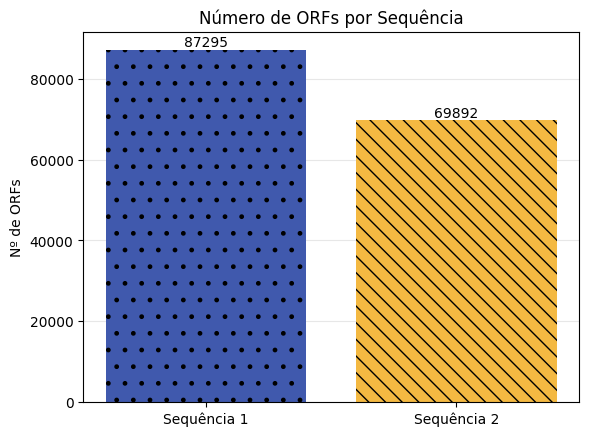

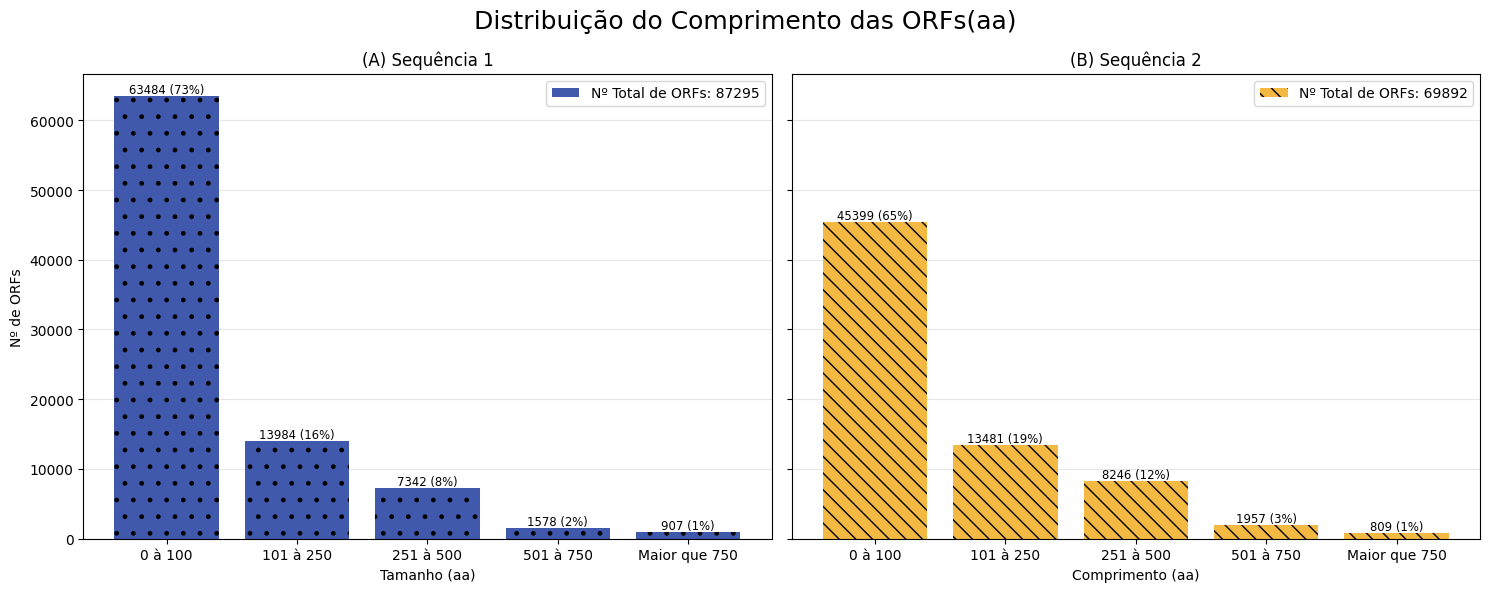

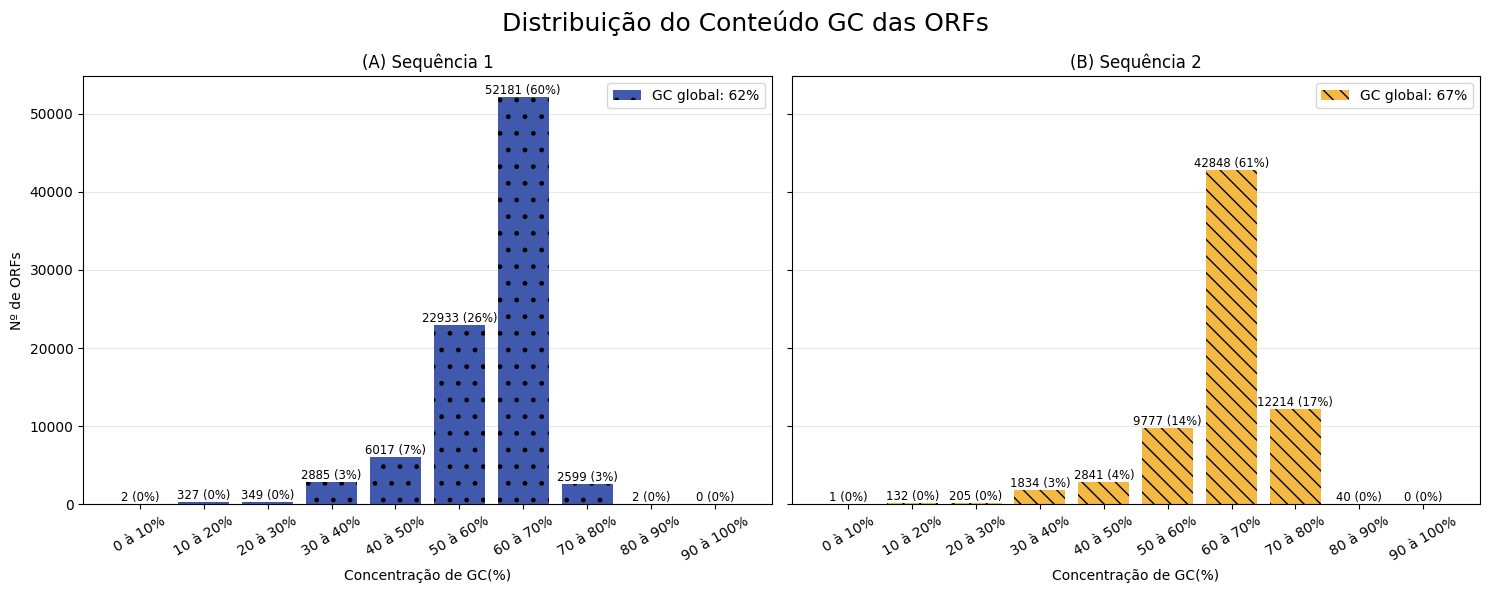

In [15]:
compara_orfs(seq_1, seq_2)